In [ ]:
# Paramdeep Choudhary
# cu24250162
# labsheet 10

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


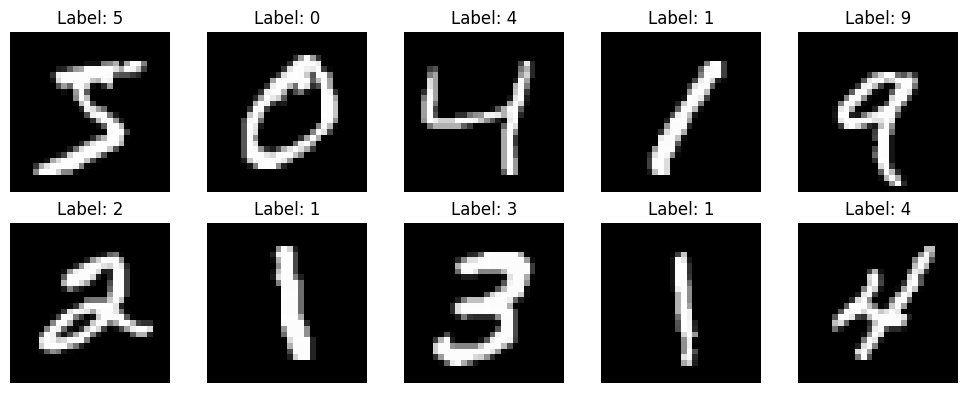

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 47s 97ms/step - accuracy: 0.8965 - loss: 0.3399 - val_accuracy: 0.9818 - val_loss: 0.0613
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 98ms/step - accuracy: 0.9694 - loss: 0.1054 - val_accuracy: 0.9840 - val_loss: 0.0508
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9763 - loss: 0.0804 - val_accuracy: 0.9898 - val_loss: 0.0376
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9805 - loss: 0.0652 - val_accuracy: 0.9900 - val_loss: 0.0326
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.9838 - loss: 0.0544 - val_accuracy: 0.9908 - val_loss: 0.0322

Test Loss: 0.0298
Test Accuracy: 98.9 %


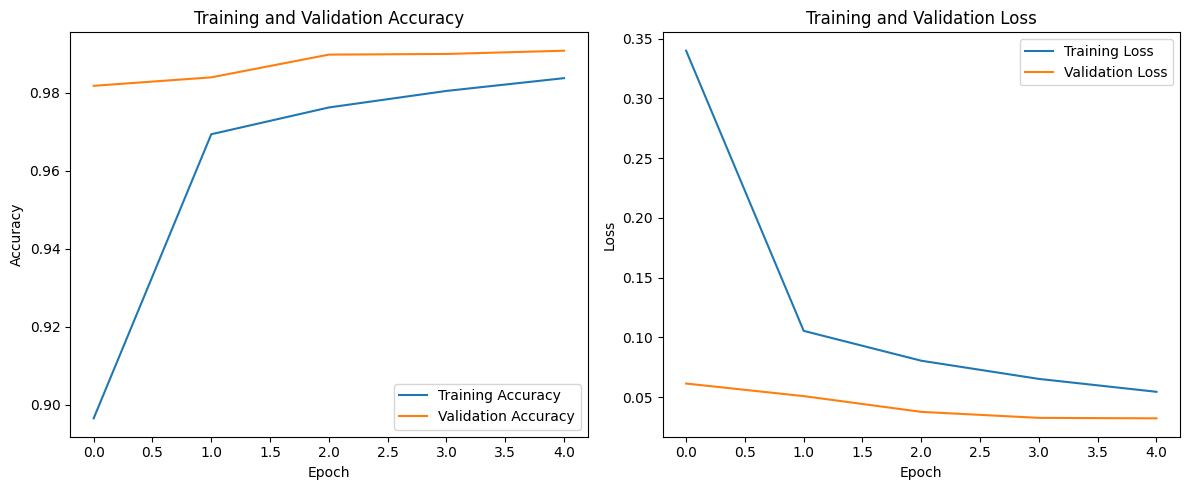

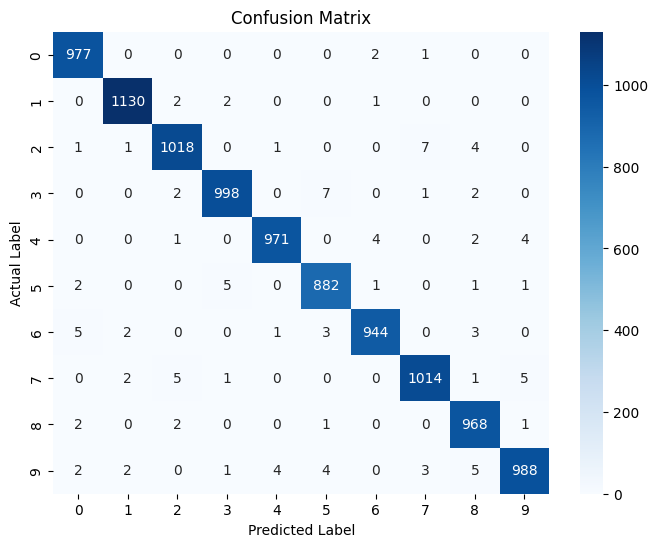


Classification Report:
              precision    recall  f1-score   support

           0     0.9879    0.9969    0.9924       980
           1     0.9938    0.9956    0.9947      1135
           2     0.9883    0.9864    0.9874      1032
           3     0.9911    0.9881    0.9896      1010
           4     0.9939    0.9888    0.9913       982
           5     0.9833    0.9888    0.9860       892
           6     0.9916    0.9854    0.9885       958
           7     0.9883    0.9864    0.9873      1028
           8     0.9817    0.9938    0.9878       974
           9     0.9890    0.9792    0.9841      1009

    accuracy                         0.9890     10000
   macro avg     0.9889    0.9889    0.9889     10000
weighted avg     0.9890    0.9890    0.9890     10000



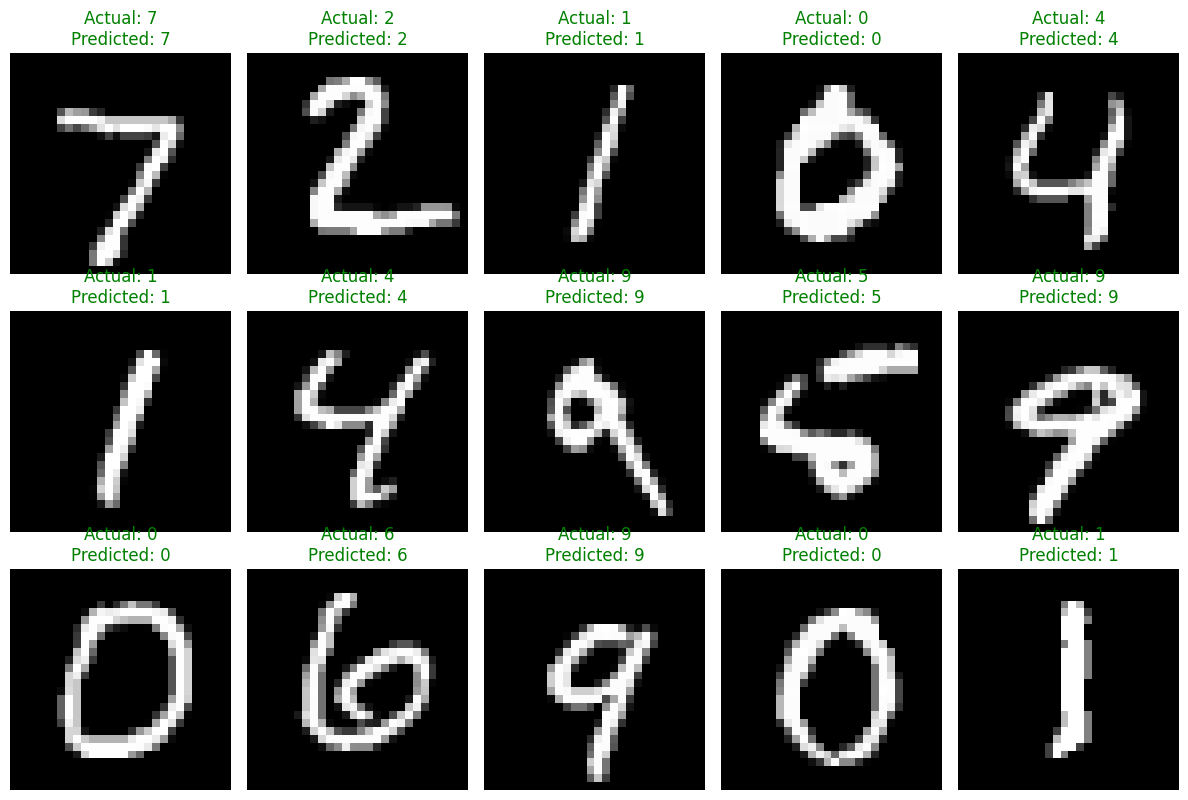


Unseen Image Prediction
Actual Digit: 7
Predicted Digit: 7
Confidence: 100.0 %

CNN model trained and saved successfully!


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

# Display sample images
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(10, activation="softmax")
])

# Display model architecture
model.summary()

# Compile model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train model
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# Evaluate model
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("\nTest Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

# Plot training and validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

# Make predictions
predictions = model.predict(x_test, verbose=0)
y_pred = np.argmax(predictions, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

# Display sample predictions
plt.figure(figsize=(12, 8))

for i in range(15):
    plt.subplot(3, 5, i + 1)

    plt.imshow(
        x_test[i].squeeze(),
        cmap="gray"
    )

    color = "green" if y_pred[i] == y_test[i] else "red"

    plt.title(
        f"Actual: {y_test[i]}\nPredicted: {y_pred[i]}",
        color=color
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Test on one unseen image
index = 0

single_image = x_test[index:index + 1]

prediction = model.predict(
    single_image,
    verbose=0
)

predicted_digit = np.argmax(prediction)

print("\nUnseen Image Prediction")
print("Actual Digit:", y_test[index])
print("Predicted Digit:", predicted_digit)
print(
    "Confidence:",
    round(float(np.max(prediction)) * 100, 2),
    "%"
)

# Save model
model.save("mnist_cnn_model.h5")

print("\nCNN model trained and saved successfully!")


In [ ]:
# Experiment No. 10
# Character, Digit, or Face Classification using Convolutional Neural Networks (CNNs)

# Q1. What is image classification? How does it differ from object detection
# and image segmentation?
#
# Answer:
# Image classification assigns one or more class labels to an entire image.
# Object detection identifies objects and their locations using bounding boxes.
# Image segmentation classifies individual pixels to identify the exact shape
# and region of each object.
# Thus, classification gives image-level labels, detection gives labels with
# bounding boxes, and segmentation provides pixel-level information.


# Q2. Explain the architecture and working principle of a CNN.
#
# Answer:
# A Convolutional Neural Network (CNN) is a deep learning model mainly used
# for processing image data.
# A typical CNN consists of convolutional layers, activation functions,
# pooling layers, flattening, fully connected layers, and an output layer.
# Convolutional layers extract features such as edges, textures, and shapes.
# Pooling layers reduce the spatial size of feature maps.
# Fully connected layers use the extracted features for classification.
# The output layer provides the probability of each class.


# Q3. What is the role of Convolutional Layers, Pooling Layers,
# and Fully Connected Layers in a CNN?
#
# Answer:
# Convolutional layers use filters to extract important features from images.
# They can detect edges, textures, shapes, and other visual patterns.
# Pooling layers reduce the size of feature maps and decrease computational
# requirements while retaining important information.
# Fully connected layers combine the extracted features and perform the
# final classification of the input image.


# Q4. Why is image normalization performed before training a deep learning model?
#
# Answer:
# Image normalization scales pixel values to a smaller and consistent range.
# For example, MNIST pixel values range from 0 to 255 and are divided by 255
# to obtain values between 0 and 1.
# Normalization improves numerical stability and helps the neural network
# train more efficiently and converge faster.


# Q5. Explain the purpose of activation functions such as ReLU and Softmax in CNNs.
#
# Answer:
# ReLU stands for Rectified Linear Unit and is commonly used in hidden layers.
# It introduces non-linearity into the network and is defined as max(0, x).
# Softmax is commonly used in the output layer for multi-class classification.
# It converts output values into probabilities for different classes.
# The class having the highest probability is selected as the prediction.


# Q6. What is a Confusion Matrix? How is it used to evaluate classification performance?
#
# Answer:
# A Confusion Matrix is a table that compares actual class labels with
# predicted class labels.
# Correct predictions are generally represented along the diagonal.
# Incorrect predictions appear outside the diagonal.
# It helps identify which classes are correctly classified and which classes
# are being confused with one another.
# It is useful for calculating performance measures such as precision,
# recall, and other classification metrics.


# Q7. Differentiate between Accuracy, Precision, Recall, and F1-Score
# with suitable examples.
#
# Answer:
# Accuracy is the proportion of total predictions that are correct.
# Accuracy = Correct Predictions / Total Predictions.
#
# Precision measures how many of the predicted positive samples are actually
# positive.
# Precision = True Positives / (True Positives + False Positives).
#
# Recall measures how many of the actual positive samples are correctly detected.
# Recall = True Positives / (True Positives + False Negatives).
#
# F1-Score is the harmonic mean of Precision and Recall.
# F1-Score = 2 × (Precision × Recall) / (Precision + Recall).
#
# For example, if a classifier correctly predicts 95 out of 100 images,
# its accuracy is 95 percent.
# Precision, recall, and F1-score provide additional information about the
# types of classification errors made by the model.


# Q8. Compare traditional feature-based image classification methods
# such as SIFT/HOG + SVM with CNN-based classification.
#
# Answer:
# Traditional methods use manually designed features such as SIFT or HOG
# and then use a classifier such as SVM.
# CNNs automatically learn useful features directly from training images.
# Traditional methods require manual feature extraction, while CNNs learn
# hierarchical features such as edges, textures, shapes, and complex patterns.
# CNNs generally require more computational resources and training data,
# but they can achieve strong performance on large image datasets.


# Q9. Mention five real-world applications of CNN-based image classification.
#
# Answer:
# 1. Handwritten digit and character recognition.
# 2. Face recognition and biometric identification.
# 3. Medical image classification.
# 4. Product and image classification in retail.
# 5. Industrial defect and quality inspection.


# Q10. How can techniques such as Data Augmentation, Transfer Learning,
# and Hyperparameter Tuning improve the performance of deep learning-based
# image classification models?
#
# Answer:
# Data Augmentation creates additional training examples using transformations
# such as rotation, cropping, scaling, and flipping.
# It can improve generalization and reduce overfitting.
#
# Transfer Learning uses a pre-trained model that has already learned useful
# features from a large dataset.
# It can reduce training time and the amount of training data required.
#
# Hyperparameter Tuning involves selecting suitable values for parameters
# such as learning rate, batch size, number of epochs, number of filters,
# and dropout rate.
# Proper tuning can improve model accuracy and training performance.


# Conclusion:
# A Convolutional Neural Network was successfully designed and trained using
# the MNIST handwritten digit dataset.
# The CNN automatically learned important image features and classified
# handwritten digits into ten classes from 0 to 9.
# The model was evaluated using accuracy, precision, recall, F1-score,
# and a confusion matrix.
# CNN-based image classification is widely used in modern computer vision
# applications.
